<a href="https://colab.research.google.com/github/kaifkh20/d2l/blob/main/alex_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install d2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.9 MB/s eta 0:00:00


In [31]:
import torch
from torch import nn
import torch.optim as optim
from d2l import torch as d2l


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: {device}")

Using device: cuda


In [4]:
class AlexNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes))
        self.net.apply(d2l.init_cnn)


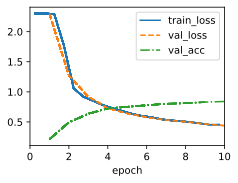

In [6]:
model = AlexNet(lr=0.01)
model.to(device)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
trainer.fit(model, data)


In [7]:
# Get total parameter memory
param_size = sum(p.numel() * p.element_size() for p in model.parameters())
print(f"Model Parameters Memory: {param_size / (1024**2):.2f} MB")

Model Parameters Memory: 178.39 MB


**PYTORCHIC WAY**


In [33]:
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
train_loader = data.get_dataloader(train=True)
val_loader = data.get_dataloader(train=False)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [34]:
sample_x,sample_y = next(iter(train_loader))
sample_x.shape

torch.Size([128, 1, 224, 224])

In [35]:
class AlexNetPT(nn.Module):
  def __init__(self,num_classes=10):
    super().__init__()
    self.net = nn.Sequential(
        nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes)
      )

  def forward(self,X):
    return self.net(X)

In [36]:
def he_init(m):
  if isinstance(m,(nn.LazyConv2d,nn.LazyLinear)):
    nn.init.kaiming_uniform_(m.weight,a=0,mode='fan_in',nonlinearity='relu')

    if m.bias is not None:
      nn.init.zeros_(m.bias)

In [37]:
#initalizaing model with sample input to apply kaiming_uniform
sample_x = sample_x.to(device)
model1 = AlexNetPT(num_classes=10)
model1.to(device)
_ = model1(sample_x)
model1.apply(he_init)
model1(sample_x).shape

torch.Size([128, 10])

In [38]:
lr = 0.01
optimizer = optim.SGD(model1.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

for epoch in range(num_epochs):
    # ---------- Training ----------
    model1.train()  # set model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        output = model1(X)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)
        _, predicted = output.max(1)
        train_correct += (predicted == y).sum().item()
        train_total += y.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ---------- Validation ----------
    model1.eval()  # set model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            output_val = model1(X_val)
            loss_val = criterion(output_val, y_val)
            '''
                #loss_val.item() gives average loss over the batch but we need loss over each
                But we want to calculate the total loss across the entire validation set
                so that when we divide by the total number of samples,
                we get the true average loss over all samples,
                even if the last batch is smaller than the others.
            '''
            val_loss += loss_val.item() * X_val.size(0)
            _, predicted_val = output_val.max(1) #argmax
            val_correct += (predicted_val == y_val).sum().item()
            val_total += y_val.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/10 | Train Loss: 2.3018, Train Acc: 0.1058 | Val Loss: 2.3005, Val Acc: 0.1000
Epoch 2/10 | Train Loss: 2.2943, Train Acc: 0.1436 | Val Loss: 2.2554, Val Acc: 0.1679
Epoch 3/10 | Train Loss: 1.2681, Train Acc: 0.5088 | Val Loss: 0.9143, Val Acc: 0.6546
Epoch 4/10 | Train Loss: 0.8599, Train Acc: 0.6662 | Val Loss: 0.7567, Val Acc: 0.7176
Epoch 5/10 | Train Loss: 0.7378, Train Acc: 0.7188 | Val Loss: 0.6879, Val Acc: 0.7445
Epoch 6/10 | Train Loss: 0.6414, Train Acc: 0.7592 | Val Loss: 0.6085, Val Acc: 0.7653
Epoch 7/10 | Train Loss: 0.5720, Train Acc: 0.7848 | Val Loss: 0.6083, Val Acc: 0.7604
Epoch 8/10 | Train Loss: 0.5206, Train Acc: 0.8041 | Val Loss: 0.5107, Val Acc: 0.8113
Epoch 9/10 | Train Loss: 0.4857, Train Acc: 0.8174 | Val Loss: 0.4632, Val Acc: 0.8260
Epoch 10/10 | Train Loss: 0.4590, Train Acc: 0.8303 | Val Loss: 0.4426, Val Acc: 0.8372


In [39]:
# Get total parameter memory
param_size = sum(p.numel() * p.element_size() for p in model1.parameters())
print(f"Model Parameters Memory: {param_size / (1024**2):.2f} MB")

Model Parameters Memory: 178.39 MB
